# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [62]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

import urllib.request
import matplotlib.pyplot as plt
import MyFunctions as mf    

## 2. Datos

In [63]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df = pd.read_csv("./data/train.csv")

### 2.1 Exploración de los datos

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    object 
 2   Product           912 non-null    object 
 3   TypeName          912 non-null    object 
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    object 
 6   Cpu               912 non-null    object 
 7   Ram               912 non-null    object 
 8   Memory            912 non-null    object 
 9   Gpu               912 non-null    object 
 10  OpSys             912 non-null    object 
 11  Weight            912 non-null    object 
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 92.8+ KB


In [65]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [66]:
df.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
907,28,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,800.00
908,1160,HP,Spectre Pro,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.48kg,1629.00
909,78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,2TB HDD,Intel HD Graphics 620,No OS,2.2kg,519.00
910,23,HP,255 G6,Notebook,15.6,1366x768,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,No OS,1.86kg,258.00
911,229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34


In [67]:
df.describe()

,laptop_ID,Inches,Price_in_euros
count,912.000000,912.000000,912.000000
mean,650.312500,14.981579,1111.724090
std,382.727748,1.436719,687.959172
min,2.000000,10.100000,174.000000
25%,324.750000,14.000000,589.000000
50%,636.500000,15.600000,978.000000
75%,982.250000,15.600000,1483.942500
max,1320.000000,18.400000,6099.000000


In [68]:
# Hacemos que nuestro índice sea el id
df.set_index("laptop_ID", inplace=True)

In [69]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [70]:
df_full = pd.read_csv("./data/laptops.csv", encoding='latin1')

### 2.3 Dividir X_train, X_test, y_train, y_test

In [71]:
train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)

In [72]:
# Screen resolution
# Vemos que hay unas mismas caracterísitcas que se van repitiendo "Full HD", "IPS Panel", "Touchscreen"... (menos de 10)
# haremos una especie the one-hot encoding con estas características,
# creando una nueva columna para cada una de ellas, con un valor de 1 si la laptop tiene esa característica y 0 si no la tiene
# Tambien vemos que los últimos caracteres son la resolución en formato "ancho x alto",
# crearemos dos nuevas columnas, una para el ancho y otra para el alto, y eliminaremos la columna original de ScreenResolution
print(f"\n{df_full["ScreenResolution"].value_counts()}")

mf.screen_resolution_split(train_set)
mf.screen_resolution_split(test_set)


ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x1

In [73]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           729 non-null    object 
 1   Product           729 non-null    object 
 2   TypeName          729 non-null    object 
 3   Inches            729 non-null    float64
 4   ScreenResolution  729 non-null    int64  
 5   Cpu               729 non-null    object 
 6   Ram               729 non-null    object 
 7   Memory            729 non-null    object 
 8   Gpu               729 non-null    object 
 9   OpSys             729 non-null    object 
 10  Weight            729 non-null    object 
 11  Price_in_euros    729 non-null    float64
 12  Full HD           729 non-null    int64  
 13  IPS Panel         729 non-null    int64  
 14  Touchscreen       729 non-null    int64  
 15  4K Ultra HD       729 non-null    int64  
 16  Retina Display    729 non-null    int64  
 17 

In [74]:
# Ram
# Nos aseguramos que Las unidades son GB, y luego convertimos la columna a tipo numérico
print(f"\n{df_full["Ram"].value_counts()}")
print(f"\nValores sin GB:{train_set[~train_set['Ram'].str.contains('GB', na=False)]['Ram'].unique()}")

mf.replace_value(train_set, "Ram", "GB", "", int)
mf.replace_value(test_set, "Ram", "GB", "", int)


Ram
8GB     619
4GB     375
16GB    200
6GB      41
12GB     25
2GB      22
32GB     17
24GB      3
64GB      1
Name: count, dtype: int64

Valores sin GB:[]


In [75]:
train_set["Ram_GB"].value_counts()

Ram_GB
8     340
4     217
16    112
6      20
12     18
2      15
32      6
64      1
Name: count, dtype: int64

In [76]:
# Weight
# Nos aseguramos que Las unidades son Kg, y luego convertimos la columna a tipo numérico
print(f"\n{df_full["Weight"].value_counts()}")
print(f"\nValores sin Kg:{train_set[~train_set['Weight'].str.contains('kg', na=False)]['Weight'].unique()}")

mf.replace_value(train_set, "Weight", "kg", "", float)
mf.replace_value(test_set, "Weight", "kg", "", float)


Weight
2.2kg      121
2.1kg       58
2.4kg       44
2.3kg       41
2.5kg       38
          ... 
3.52kg       1
2.21kg       1
2.191kg      1
2.34kg       1
4.0kg        1
Name: count, Length: 179, dtype: int64

Valores sin Kg:[]


In [77]:
train_set["Weight_kg"].value_counts()

Weight_kg
2.20    76
2.10    33
2.00    28
2.40    25
2.50    24
        ..
2.16     1
0.91     1
2.15     1
1.94     1
1.18     1
Name: count, Length: 142, dtype: int64

In [78]:
# Memory
# Vemos que tenemos estos tipos de memoria: SSD, HDD, Flash Storage, Hybrid
# haremos una especie the one-hot encoding con estas características,
# creando una nueva columna para cada una de ellas, con un valor de 1 si la laptop tiene esa característica y 0 si no la tiene
# Tambien vemos que a veces hay dos tipos de memoria separados por un "+", crearemos dos nuevas columnas, 
# una para cada tipo de memoria, y eliminaremos la columna original de Memory
print(f"\n{df_full["Memory"].value_counts()}")

print(f"\nValores sin GB o TB:{train_set[~train_set['Memory'].str.contains('GB|TB', na=False)]['Memory'].unique()}")

mf.memory_split2(train_set)
mf.memory_split2(test_set)



Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                      

In [79]:
# CPU
# Vemos que el valor de la columna empieza con el nombre del fabricante del procesador, 
# y acaba con la velocidad en GHz.
# El resto de información es el modelo del procesador, a mi entender no es relevante y lo obviamos
print(f"\n{df_full["Cpu"].value_counts()}")

print(f"\nValores sin GHz:{train_set[~train_set['Cpu'].str.contains('GHz', na=False)]['Cpu'].unique()}")

mf.cpu_split2(train_set)
mf.cpu_split2(test_set)


Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

Valores sin GHz:[]


In [80]:
train_set["Cpu_Brand"].value_counts()
train_set["Cpu_Family"].value_counts()

Cpu_Family
Core i7    299
Core i5    232
Core i3     74
Celeron     52
Other       48
Pentium     23
Xeon         1
Name: count, dtype: int64

In [81]:
# GPU
# Vemos que el valor de la columna empieza con el nombre del fabricante.
# El resto de información es el modelo de la tarjeta gráfica, a mi entender no es relevante y lo obviamos
print(f"\n{df_full["Gpu"].value_counts()}")

# mf.gpu_split(train_set)
# mf.gpu_split(test_set)

mf.gpu_split2(train_set)
mf.gpu_split2(test_set)


Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64


In [82]:
train_set["Gpu_Brand"].value_counts()

Gpu_Brand
Intel     417
Nvidia    220
AMD        92
Name: count, dtype: int64

In [83]:
# Product
# Vemos hay muchos productos diferentes, por lo que no es útil para nuestro modelo, así que la eliminamos
print(f"\n{df_full["Product"].value_counts()}")


Product
XPS 13                                   30
Inspiron 3567                            29
250 G6                                   21
Vostro 3568                              19
Legion Y520-15IKBN                       19
                                         ..
ThinkPad L460                             1
V510-15IKB (i5-7200U/8GB/256GB/FHD/No     1
Rog GL502VS                               1
Rog GL553VE-FY052T                        1
17-ak001nv (A6-9220/4GB/500GB/Radeon      1
Name: count, Length: 618, dtype: int64


In [84]:
# No aporta valor
train_set.drop("Product", axis=1, inplace=True)
test_set.drop("Product", axis=1, inplace=True)

In [85]:
# OpSys
# Vemos que hay pocos sistemas operativos diferentes.
# Trataremos más tarde las categóricas que nos quedan
print(f"\n{df_full["OpSys"].value_counts()}")


OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64


In [86]:
# Modificar los valores de OpSys que contengan "Windows" por "Windows" 
# y los que contienen "Mac" por "Mac", para reducir el número de categorías
# Modificar valores de OpSys
train_set['OpSys'] = train_set['OpSys'].str.upper()

train_set['OpSys'] = train_set['OpSys'].apply(
    lambda x: "WINDOWS" if "WINDOWS" in x else ("MAC" if "MAC" in x else x)
)

test_set['OpSys'] = test_set['OpSys'].str.upper()

test_set['OpSys'] = test_set['OpSys'].apply(
    lambda x: "WINDOWS" if "WINDOWS" in x else ("MAC" if "MAC" in x else x)
)



In [87]:
print(f"\n{train_set['OpSys'].value_counts()}")


OpSys
WINDOWS      625
NO OS         39
LINUX         37
CHROME OS     14
MAC           13
ANDROID        1
Name: count, dtype: int64


In [88]:
# Company
# Vemos que hay varias varias marcas diferentes, pero algunas de ellas tienen muy pocas muestras, 
# por lo que las agrupamos en "Other"
print(f"\n{df_full["Company"].value_counts()}")

mf.other_grouping(train_set, "Company", 10)
mf.other_grouping(test_set, "Company", 10)


Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
Fujitsu        3
Google         3
LG             3
Huawei         2
Name: count, dtype: int64


In [89]:
train_set["Company"].value_counts()

Company
Lenovo     162
Dell       158
HP         155
Asus       101
Acer        55
Toshiba     31
MSI         30
Other       24
Apple       13
Name: count, dtype: int64

In [90]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           729 non-null    object 
 1   TypeName          729 non-null    object 
 2   Inches            729 non-null    float64
 3   ScreenResolution  729 non-null    int64  
 4   OpSys             729 non-null    object 
 5   Price_in_euros    729 non-null    float64
 6   Full HD           729 non-null    int64  
 7   IPS Panel         729 non-null    int64  
 8   Touchscreen       729 non-null    int64  
 9   4K Ultra HD       729 non-null    int64  
 10  Retina Display    729 non-null    int64  
 11  Quad HD+          729 non-null    int64  
 12  Ram_GB            729 non-null    int64  
 13  Weight_kg         729 non-null    float64
 14  Memory_GB         729 non-null    int64  
 15  SSD               729 non-null    int64  
 16  HDD               729 non-null    int64  
 17 

In [91]:
# Tratamiento de categóricas
# Company, TypeName y OpSys tienen muchas categorías diferentes, haremos un target encoding, 
# asignando a cada categoría el valor medio de la variable objetivo (Price_in_euros) para esa categoría.

# Target encoding para Company, TypeName y opSys
features_big_cat = ["Company", "TypeName", "OpSys"]

# mf.target_encoding(test_set, train_set, features_big_cat, "Price_in_euros")
# mf.target_encoding(train_set, train_set, features_big_cat, "Price_in_euros")

mf.frequency_encoding(train_set, features_big_cat)
mf.frequency_encoding(test_set, features_big_cat)


In [92]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Inches            729 non-null    float64
 1   ScreenResolution  729 non-null    int64  
 2   Price_in_euros    729 non-null    float64
 3   Full HD           729 non-null    int64  
 4   IPS Panel         729 non-null    int64  
 5   Touchscreen       729 non-null    int64  
 6   4K Ultra HD       729 non-null    int64  
 7   Retina Display    729 non-null    int64  
 8   Quad HD+          729 non-null    int64  
 9   Ram_GB            729 non-null    int64  
 10  Weight_kg         729 non-null    float64
 11  Memory_GB         729 non-null    int64  
 12  SSD               729 non-null    int64  
 13  HDD               729 non-null    int64  
 14  Flash Storage     729 non-null    int64  
 15  Hybrid            729 non-null    int64  
 16  Speed_GHz         729 non-null    float64
 17 

In [93]:
# Finalmente, nos quedan 2 columnas categóricas, GPU y CPU, que tienen pocas categorías diferentes, 
# por lo que haremos un one-hot encoding para estas columnas.
features_small_cat = ["Cpu_Brand", "Gpu_Brand", "Cpu_Family", "Gpu_Family"]

train_set = mf.one_hot_encoding(train_set, features_small_cat)
test_set = mf.one_hot_encoding(test_set, features_small_cat)

In [94]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Inches                  729 non-null    float64
 1   ScreenResolution        729 non-null    int64  
 2   Price_in_euros          729 non-null    float64
 3   Full HD                 729 non-null    int64  
 4   IPS Panel               729 non-null    int64  
 5   Touchscreen             729 non-null    int64  
 6   4K Ultra HD             729 non-null    int64  
 7   Retina Display          729 non-null    int64  
 8   Quad HD+                729 non-null    int64  
 9   Ram_GB                  729 non-null    int64  
 10  Weight_kg               729 non-null    float64
 11  Memory_GB               729 non-null    int64  
 12  SSD                     729 non-null    int64  
 13  HDD                     729 non-null    int64  
 14  Flash Storage           729 non-null    int6

In [95]:
#train_set["Company_Freq"].value_counts()

In [96]:
train_set.to_csv("my_df.csv") 

Text(0.5, 0, 'Price in euros')

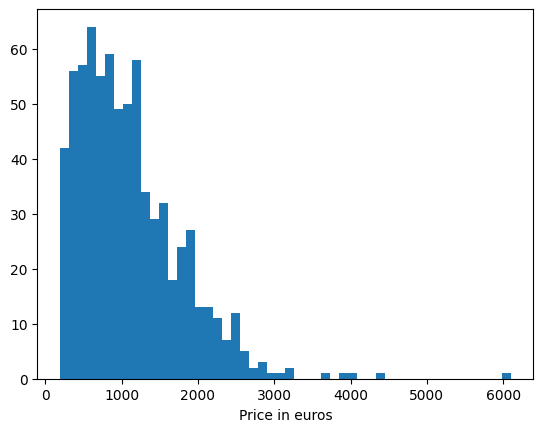

In [97]:
# Correlaciones, distribución de la variable objetivo, etc... 

# Distribución de la variable objetivo

plt.hist(train_set["Price_in_euros"], bins=50)
plt.xlabel("Price in euros")


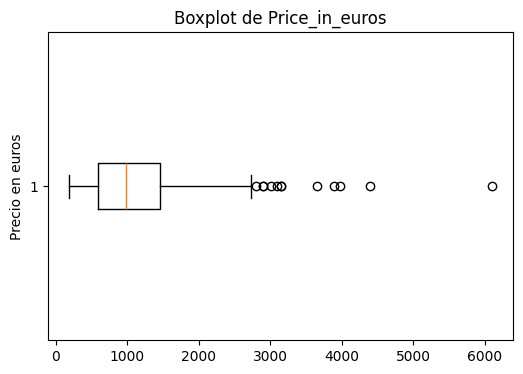

In [98]:
# Distribución de la variable objetivo

plt.figure(figsize=(6, 4))
plt.boxplot(train_set['Price_in_euros'], vert=False)
plt.title('Boxplot de Price_in_euros')
plt.ylabel('Precio en euros')
plt.show()


In [99]:
# Outliers en la variable objetivo
mf.outlier_iqr(train_set, "Price_in_euros")


Outliers in Price_in_euros: 
    laptop_ID  Price_in_euros
0        1118         2899.00
1         731         3659.40
2         243         3890.00
3         924         3100.00
4         431         2799.00
5         982         3149.00
6        1081         3975.00
7         537         3012.77
8         667         3147.37
9         787         2899.00
10        200         6099.00
11        758         4389.00


In [100]:
# Hay varios outliers en la variable objetivo, 
# aplicaremos un logaritmo a la variable objetivo para reducir el impacto de estos outliers en nuestro modelo
# train_set["Price_in_euros"] = np.log(train_set["Price_in_euros"])
# test_set["Price_in_euros"] = np.log(test_set["Price_in_euros"])

# Calcular el valor del percentil 99
cap_value = train_set["Price_in_euros"].quantile(0.95)

# Limitar los valores extremos
train_set["Price_in_euros"] = np.where(
    train_set["Price_in_euros"] > cap_value,
    cap_value,
    train_set["Price_in_euros"]
)

train_set["Price_in_euros"] = np.log(train_set["Price_in_euros"])
test_set["Price_in_euros"] = np.log(test_set["Price_in_euros"])

In [101]:
# Outliers en la variable objetivo
mf.outlier_iqr(train_set, "Price_in_euros")


Outliers in Price_in_euros: 
Empty DataFrame
Columns: [laptop_ID, Price_in_euros]
Index: []


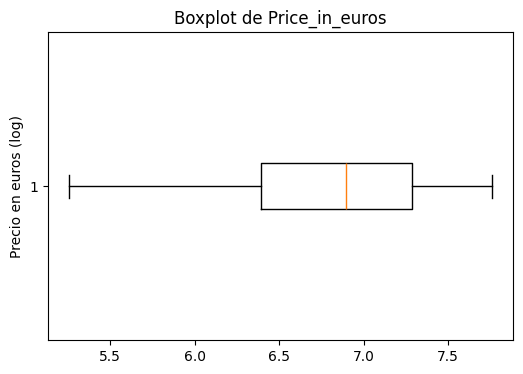

In [102]:
plt.figure(figsize=(6, 4))
plt.boxplot(train_set['Price_in_euros'], vert=False)
plt.title('Boxplot de Price_in_euros')
plt.ylabel('Precio en euros (log)')
plt.show()

In [103]:
# Outliers en la variable objetivo logaritmizada
mf.outlier_iqr(train_set, "Price_in_euros")


Outliers in Price_in_euros: 
Empty DataFrame
Columns: [laptop_ID, Price_in_euros]
Index: []


In [104]:
# Correlaciones con la variable objetivo logaritmizada
correlations = train_set.corr()["Price_in_euros"].sort_values(ascending=False)
print(correlations)

Price_in_euros            1.000000
Ram_GB                    0.644470
SSD                       0.599181
Cpu_Family_Core i7        0.590360
Speed_GHz                 0.497855
ScreenResolution          0.475610
Full HD                   0.384335
Gpu_Brand_Nvidia          0.333271
IPS Panel                 0.292812
Gpu_Family_GeForce        0.290298
OpSys_Freq                0.287285
Touchscreen               0.236805
Cpu_Brand_Intel           0.226730
4K Ultra HD               0.208291
Gpu_Family_Quadro         0.172061
Memory_GB                 0.166185
Quad HD+                  0.152392
Weight_kg                 0.113953
Gpu_Family_Iris           0.108601
Retina Display            0.105208
Cpu_Family_Xeon           0.057809
Cpu_Family_Core i5        0.053394
Inches                    0.016000
Hybrid                   -0.012073
Company_Freq             -0.023095
Gpu_Family_Other         -0.033150
HDD                      -0.165207
Gpu_Brand_Intel          -0.187029
Gpu_Family_Radeon   

In [105]:
# Value counts de las variables categóricas
for col in [c for c in train_set.columns if c != "Price_in_euros"]:
    counts = train_set[col].value_counts()
    if len(counts) > 2:
        print(f"\n{train_set[col].value_counts()}")
        # mf.other_grouping(train_set, col, threshold=10)
        # print(f"\n{train_set[col].value_counts()}")


Inches
15.6    362
14.0    115
13.3     99
17.3     95
12.5     21
11.6     20
12.0      3
13.5      3
12.3      2
15.4      2
15.0      2
13.9      2
10.1      1
14.1      1
11.3      1
Name: count, dtype: int64

ScreenResolution
2073600    464
1049088    179
8294400     21
5760000     20
1440000     14
3686400     13
1296000      4
4096000      3
3317760      3
3393024      3
3840000      2
5184000      2
2304000      1
Name: count, dtype: int64

Ram_GB
8     340
4     217
16    112
6      20
12     18
2      15
32      6
64      1
Name: count, dtype: int64

Weight_kg
2.20    76
2.10    33
2.00    28
2.40    25
2.50    24
        ..
2.16     1
0.91     1
2.15     1
1.94     1
1.18     1
Name: count, Length: 142, dtype: int64

Memory_GB
256     233
1024    135
500      80
512      64
1152     56
128      50
1280     43
32       26
64        9
2048      8
1536      6
2304      6
16        5
180       2
2560      2
240       1
8         1
2176      1
508       1
Name: count, dtype: int

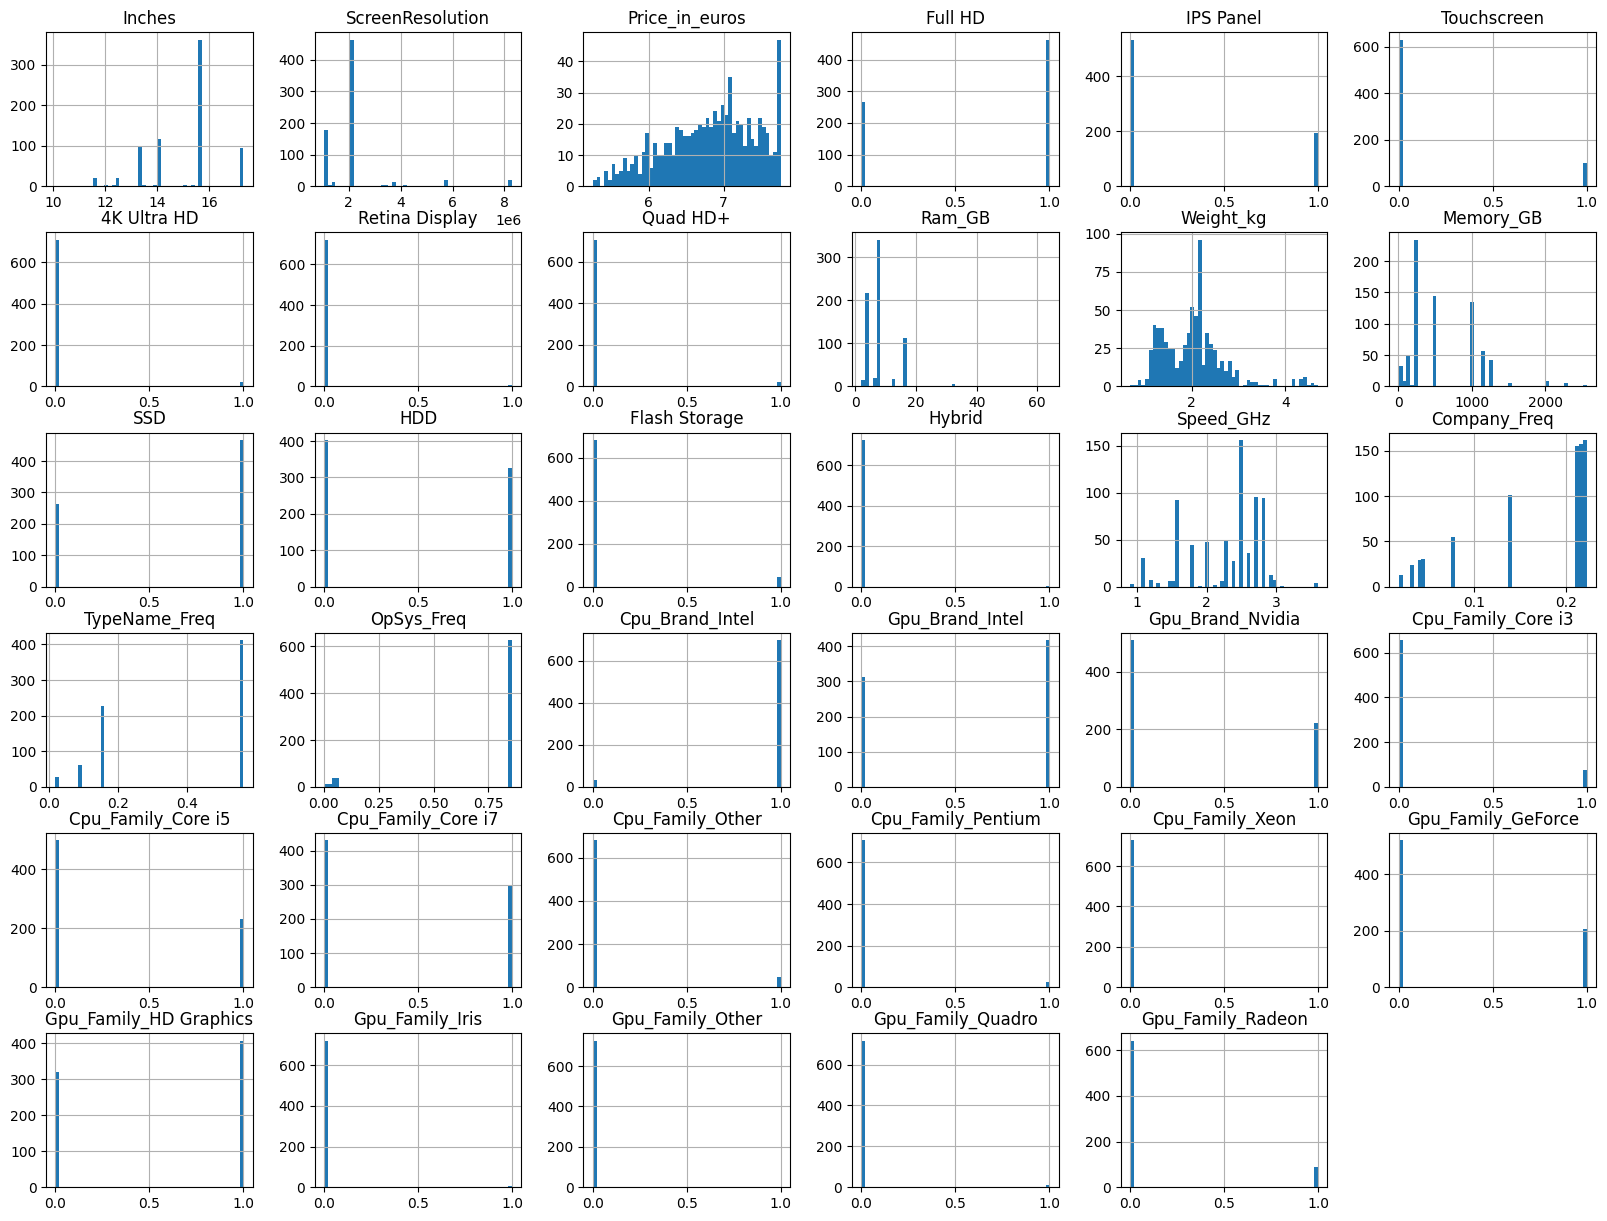

In [106]:
# Distribución de todas las features
train_set.hist(bins=50, figsize=(20, 15))
plt.show()


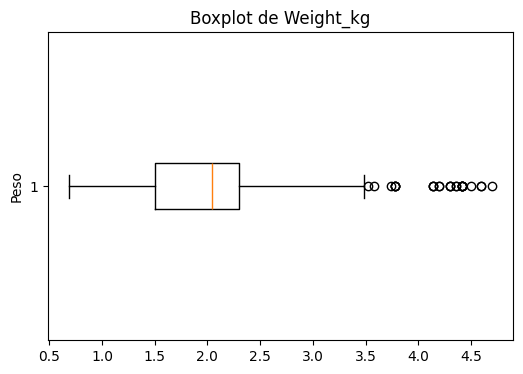

In [107]:
plt.figure(figsize=(6, 4))
plt.boxplot(train_set['Weight_kg'], vert=False)
plt.title('Boxplot de Weight_kg')
plt.ylabel('Peso')
plt.show()

In [108]:
# features_scaler = ["Inches","Weight_kg","Speed_GHz","ScreenResolution","Ram_GB", "Memory_GB"]

# for feature in features_scaler:
#     train_set[feature] = np.log(train_set[feature])
#     test_set[feature] = np.log(test_set[feature])

train_set["Weight_kg"] = np.log(train_set["Weight_kg"])
test_set["Weight_kg"] = np.log(test_set["Weight_kg"])

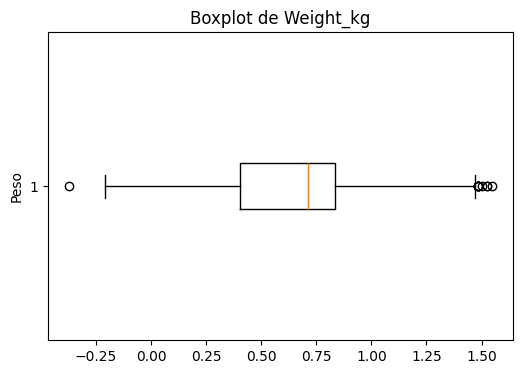

In [109]:
plt.figure(figsize=(6, 4))
plt.boxplot(train_set['Weight_kg'], vert=False)
plt.title('Boxplot de Weight_kg')
plt.ylabel('Peso')
plt.show()

In [110]:
# Outliers en la variable peso logaritmizada
mf.outlier_iqr(train_set, "Weight_kg")


Outliers in Weight_kg: 
    laptop_ID  Weight_kg
0         243   1.547563
1         584   1.526056
2         592   1.504077
3         431   1.486140
4        1129  -0.371064
5         559   1.486140
6         982   1.486140
7         537   1.486140
8         229   1.486140
9        1062   1.526056
10        667   1.486140


<Axes: >

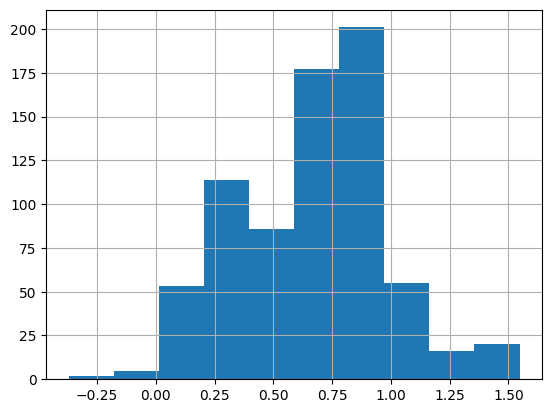

In [111]:
train_set["Weight_kg"].hist()

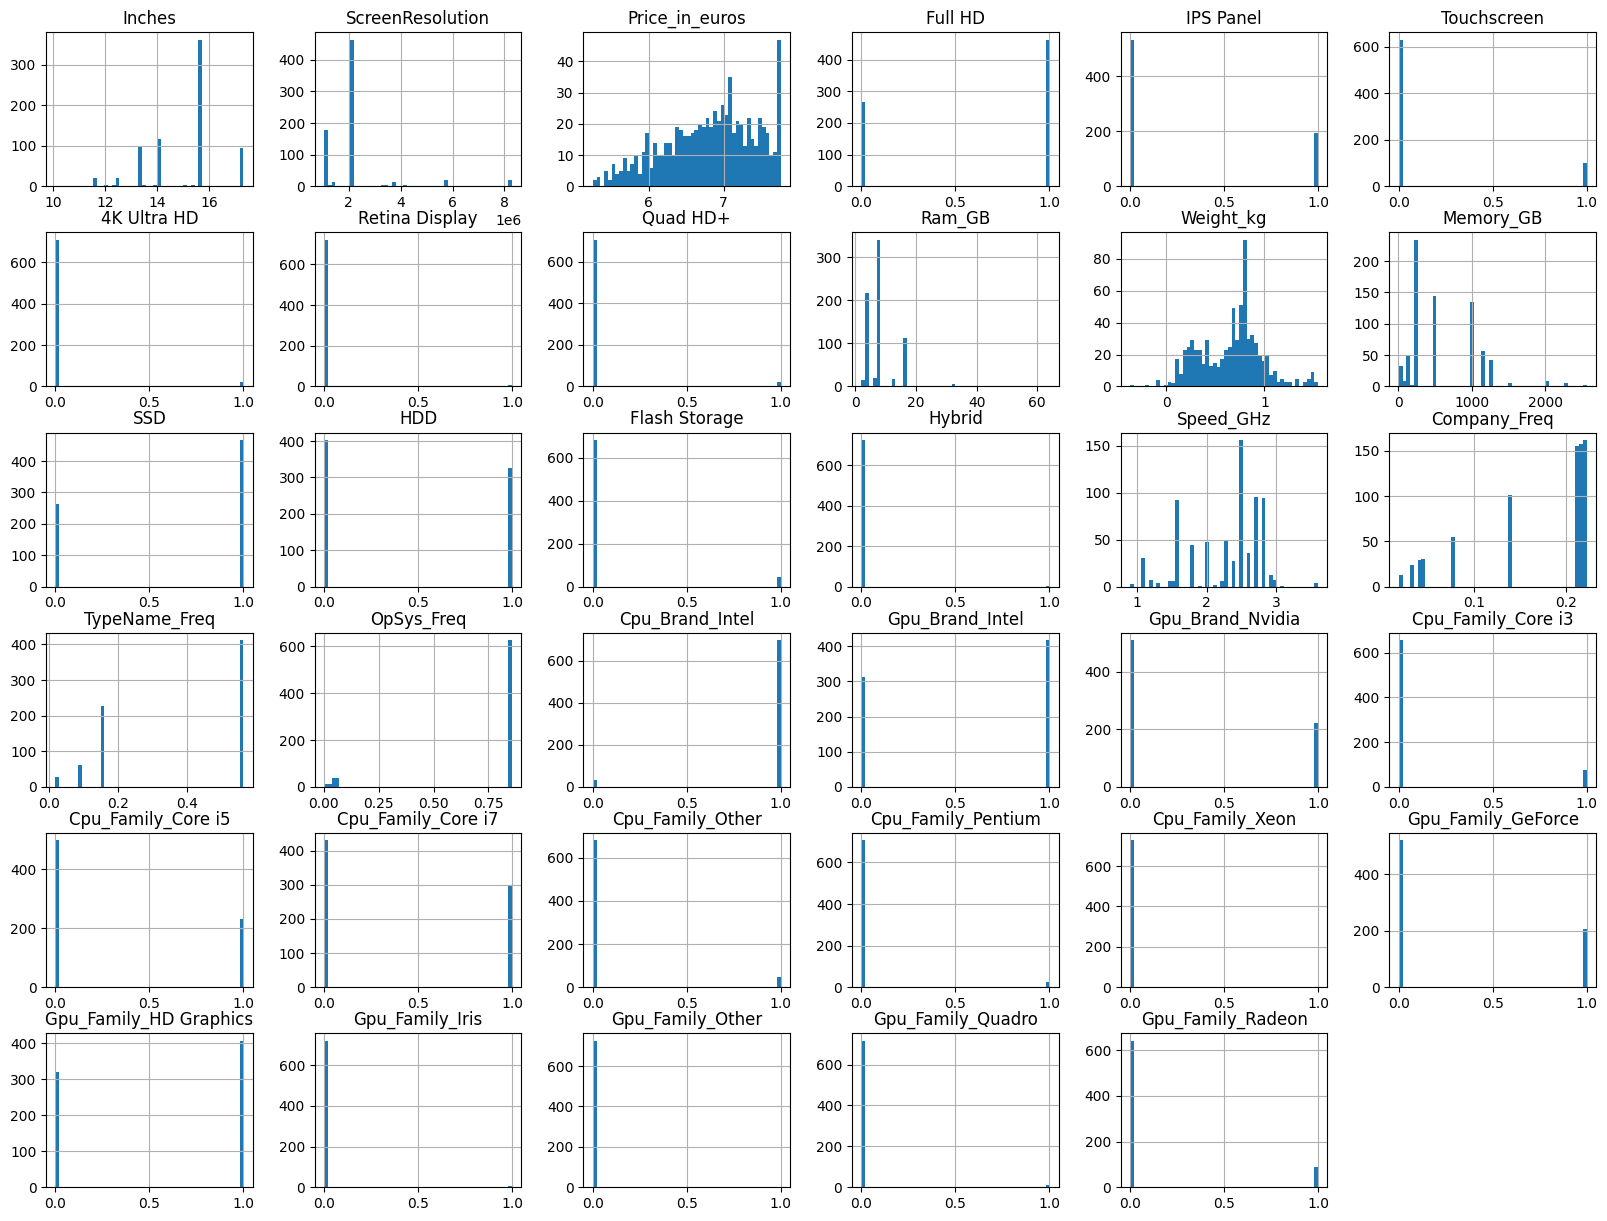

In [112]:
# Distribución de todas las features
train_set.hist(bins=50, figsize=(20, 15))
plt.show()

In [113]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Inches                  729 non-null    float64
 1   ScreenResolution        729 non-null    int64  
 2   Price_in_euros          729 non-null    float64
 3   Full HD                 729 non-null    int64  
 4   IPS Panel               729 non-null    int64  
 5   Touchscreen             729 non-null    int64  
 6   4K Ultra HD             729 non-null    int64  
 7   Retina Display          729 non-null    int64  
 8   Quad HD+                729 non-null    int64  
 9   Ram_GB                  729 non-null    int64  
 10  Weight_kg               729 non-null    float64
 11  Memory_GB               729 non-null    int64  
 12  SSD                     729 non-null    int64  
 13  HDD                     729 non-null    int64  
 14  Flash Storage           729 non-null    int6

In [114]:
#scaler = StandardScaler()

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

#features_scaler = ["Inches","Weight_kg","Speed_GHz","ScreenResolution","Ram_GB", "SSD_GB","HDD_GB","Flash Storage_GB","Hybrid_GB"]
# features_scaler = ["Inches","Weight_kg","Speed_GHz","ScreenResolution","Ram_GB", "Memory_GB"]

# train_set[features_scaler] = scaler.fit_transform(train_set[features_scaler])
# test_set[features_scaler] = scaler.transform(test_set[features_scaler])

In [115]:
# Correlaciones con la variable objetivo logaritmizada
correlations = train_set.corr()["Price_in_euros"].sort_values(ascending=False)
print(correlations)

Price_in_euros            1.000000
Ram_GB                    0.644470
SSD                       0.599181
Cpu_Family_Core i7        0.590360
Speed_GHz                 0.497855
ScreenResolution          0.475610
Full HD                   0.384335
Gpu_Brand_Nvidia          0.333271
IPS Panel                 0.292812
Gpu_Family_GeForce        0.290298
OpSys_Freq                0.287285
Touchscreen               0.236805
Cpu_Brand_Intel           0.226730
4K Ultra HD               0.208291
Gpu_Family_Quadro         0.172061
Memory_GB                 0.166185
Quad HD+                  0.152392
Gpu_Family_Iris           0.108601
Retina Display            0.105208
Cpu_Family_Xeon           0.057809
Cpu_Family_Core i5        0.053394
Weight_kg                 0.020373
Inches                    0.016000
Hybrid                   -0.012073
Company_Freq             -0.023095
Gpu_Family_Other         -0.033150
HDD                      -0.165207
Gpu_Brand_Intel          -0.187029
Gpu_Family_Radeon   

In [116]:
features_excl = [col for col in train_set.columns if col != "Price_in_euros" and (correlations[col]) < 0.3]
features_excl

['Inches',
 'IPS Panel',
 'Touchscreen',
 '4K Ultra HD',
 'Retina Display',
 'Quad HD+',
 'Weight_kg',
 'Memory_GB',
 'HDD',
 'Flash Storage',
 'Hybrid',
 'Company_Freq',
 'TypeName_Freq',
 'OpSys_Freq',
 'Cpu_Brand_Intel',
 'Gpu_Brand_Intel',
 'Cpu_Family_Core i3',
 'Cpu_Family_Core i5',
 'Cpu_Family_Other',
 'Cpu_Family_Pentium',
 'Cpu_Family_Xeon',
 'Gpu_Family_GeForce',
 'Gpu_Family_HD Graphics',
 'Gpu_Family_Iris',
 'Gpu_Family_Other',
 'Gpu_Family_Quadro',
 'Gpu_Family_Radeon']

### 2.3 Definir X e y

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [117]:
target_col = "Price_in_euros"
features = [c for c in train_set.columns if c != target_col]

#features_excl = ["Hybrid_GB", "Company_Freq", "Flash Storage_GB", "HDD_GB", "Gpu_Brand_Intel", "TypeName_Freq"]
features = [f for f in features if f not in features_excl]

y_train = train_set[target_col]
y_test = test_set[target_col]

X_train = train_set[features]
X_test = test_set[features]

train_set.to_csv("my_df.csv") 

-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

### 4.1 Baseline de modelos


In [119]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Crear y entrenar el modelo
model_xgb = xgb.XGBRegressor()
model_xgb.fit(X_train, y_train)

# Predecir y evaluar
y_pred = model_xgb.predict(X_test)
y_pred_exp = np.exp(y_pred)
y_test_exp = np.exp(y_test)
rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
#rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"XGBoost RMSE: {rmse:.2f}")

XGBoost RMSE: 437.89


In [120]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}

xgbr = xgb.XGBRegressor()
grid_xgb = GridSearchCV(xgbr, param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid_xgb.fit(X_train, y_train)

print("Mejores parámetros XGBoost:", grid_xgb.best_params_)
y_pred = grid_xgb.predict(X_test)
#rmse = np.sqrt(mean_squared_error(y_test, y_pred))
y_pred_exp = np.exp(y_pred)
y_test_exp = np.exp(y_test)

rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
print(f"XGBoost RMSE: {rmse:.2f}")

Mejores parámetros XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1}
XGBoost RMSE: 420.72


In [121]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5)
    }
    model = xgb.XGBRegressor(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor score:", study.best_value)

c:\Users\jvend\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-02-09 18:34:43,566] A new study created in memory with name: no-name-04dea883-2b03-4a4e-9a41-80f66b1b4bc3
[I 2026-02-09 18:34:43,690] Trial 0 finished with value: -0.31181580765711625 and parameters: {'max_depth': 7, 'learning_rate': 0.09874098500424645, 'n_estimators': 171, 'subsample': 0.8445638819334693, 'colsample_bytree': 0.943823897906431, 'gamma': 0.873171344194052, 'reg_alpha': 3.143351422566395, 'reg_lambda': 0.9179067334287777}. Best is trial 0 with value: -0.31181580765711625.
[I 2026-02-09 18:34:43,800] Trial 1 finished with value: -0.3249637603801383 and parameters: {'max_depth': 5, 'learning_rate': 0.1892544222862343, 'n_estimators': 143, 'subsample': 0.8534133554661412, 'colsample_bytree': 

Mejores hiperparámetros: {'max_depth': 5, 'learning_rate': 0.25376784388400303, 'n_estimators': 281, 'subsample': 0.8124758354555585, 'colsample_bytree': 0.7839800551958661, 'gamma': 0.043588787249620856, 'reg_alpha': 0.020878012322348205, 'reg_lambda': 3.968226799312075}
Mejor score: -0.2744193939812401


In [122]:
import xgboost as xgb

# Supón que study.best_params contiene los mejores hiperparámetros
best_params = study.best_params

# Entrena el modelo final con esos parámetros
model_xgb_optuna = xgb.XGBRegressor(**best_params)
model_xgb_optuna.fit(X_train, y_train)

# Predice y evalúa
y_pred = model_xgb_optuna.predict(X_test)
y_pred_exp = np.exp(y_pred)
y_test_exp = np.exp(y_test)

rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))

#rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"XGBoost Optuna RMSE: {rmse:.2f}")

XGBoost Optuna RMSE: 430.71


In [123]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error


param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

lgbm = lgb.LGBMRegressor()
grid_lgb = GridSearchCV(lgbm, param_grid, cv=3, scoring='neg_root_mean_squared_error')
grid_lgb.fit(X_train, y_train)

print("Mejores parámetros LightGBM:", grid_lgb.best_params_)
y_pred = grid_lgb.predict(X_test)
y_pred_exp = np.exp(y_pred)
y_test_exp = np.exp(y_test)

rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
#rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"LightGBM RMSE: {rmse:.2f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000044 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 44
[LightGBM] [Info] Number of data points in the train set: 486, number of used features: 7
[LightGBM] [Info] Start training from score 6,816522
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [124]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5)
    }
    model = lgb.LGBMRegressor(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Mejores hiperparámetros LightGBM:", study.best_params)
print("Mejor score:", study.best_value)

[I 2026-02-09 18:34:59,557] A new study created in memory with name: no-name-6066eff5-7171-4d71-b30d-1188148a4e0b
[I 2026-02-09 18:34:59,608] Trial 0 finished with value: -0.30147856630887965 and parameters: {'num_leaves': 96, 'max_depth': 4, 'learning_rate': 0.15980465161596208, 'n_estimators': 153, 'min_child_samples': 9, 'subsample': 0.8737500619693372, 'colsample_bytree': 0.8619494360211207, 'reg_alpha': 4.09201276333418, 'reg_lambda': 3.4000658290630756}. Best is trial 0 with value: -0.30147856630887965.
[I 2026-02-09 18:34:59,654] Trial 1 finished with value: -0.3040992628086078 and parameters: {'num_leaves': 34, 'max_depth': 7, 'learning_rate': 0.13412247242753328, 'n_estimators': 140, 'min_child_samples': 30, 'subsample': 0.8167698396127956, 'colsample_bytree': 0.7273159448609221, 'reg_alpha': 3.2579627188453397, 'reg_lambda': 1.3584157706639028}. Best is trial 0 with value: -0.30147856630887965.
[I 2026-02-09 18:34:59,707] Trial 2 finished with value: -0.3004116707607298 and p

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 44
[LightGBM] [Info] Number of data points in the train set: 486, number of used features: 7
[LightGBM] [Info] Start training from score 6,816522
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

[I 2026-02-09 18:34:59,761] Trial 3 finished with value: -0.2997739715800221 and parameters: {'num_leaves': 39, 'max_depth': 6, 'learning_rate': 0.22956149754935212, 'n_estimators': 168, 'min_child_samples': 30, 'subsample': 0.8315544738736801, 'colsample_bytree': 0.9876709437920383, 'reg_alpha': 2.472400541685194, 'reg_lambda': 0.34456937282357714}. Best is trial 3 with value: -0.2997739715800221.
[I 2026-02-09 18:34:59,809] Trial 4 finished with value: -0.30043199161412765 and parameters: {'num_leaves': 83, 'max_depth': 6, 'learning_rate': 0.27395198352577593, 'n_estimators': 159, 'min_child_samples': 7, 'subsample': 0.7292681952167325, 'colsample_bytree': 0.8619766235098267, 'reg_alpha': 3.2242633098952056, 'reg_lambda': 1.5517849028781683}. Best is trial 3 with value: -0.2997739715800221.
[I 2026-02-09 18:34:59,886] Trial 5 finished with value: -0.2823294166090665 and parameters: {'num_leaves': 91, 'max_depth': 10, 'learning_rate': 0.18445909172133934, 'n_estimators': 248, 'min_chi

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-09 18:35:00,013] Trial 7 finished with value: -0.2945537973263565 and parameters: {'num_leaves': 74, 'max_depth': 5, 'learning_rate': 0.1275232667143981, 'n_estimators': 193, 'min_child_samples': 30, 'subsample': 0.799951599595032, 'colsample_bytree': 0.7511414103471429, 'reg_alpha': 0.9670894465163726, 'reg_lambda': 3.81200216720935}. Best is trial 5 with value: -0.2823294166090665.
[I 2026-02-09 18:35:00,103] Trial 8 finished with value: -0.28626613367561865 and parameters: {'num_leaves': 22, 'max_depth': 8, 'learning_rate': 0.05648439053728228, 'n_estimators': 220, 'min_child_samples': 22, 'subsample': 0.8346206666777478, 'colsample_bytree': 0.9565486624484489, 'reg_alpha': 0.16931173315434644, 'reg_lambda': 0.7830799530382315}. Best is trial 5 with value: -0.2823294166090665.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-09 18:35:01,917] Trial 27 finished with value: -0.2806150882136675 and parameters: {'num_leaves': 89, 'max_depth': 9, 'learning_rate': 0.07521138089532867, 'n_estimators': 269, 'min_child_samples': 15, 'subsample': 0.8051051271764377, 'colsample_bytree': 0.9142222193989595, 'reg_alpha': 0.24010400872496646, 'reg_lambda': 1.0731853155383804}. Best is trial 23 with value: -0.2777269746062601.
[I 2026-02-09 18:35:01,977] Trial 28 finished with value: -0.2966428470485216 and parameters: {'num_leaves': 39, 'max_depth': 7, 'learning_rate': 0.17468136917661736, 'n_estimators': 233, 'min_child_samples': 18, 'subsample': 0.7000183498095442, 'colsample_bytree': 0.8836603476030679, 'reg_alpha': 2.0207587650521748, 'reg_lambda': 1.757809280023752}. Best is trial 23 with value: -0.2777269746062601.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-09 18:35:02,053] Trial 29 finished with value: -0.28359519593684007 and parameters: {'num_leaves': 52, 'max_depth': 8, 'learning_rate': 0.15102865452087766, 'n_estimators': 256, 'min_child_samples': 8, 'subsample': 0.7332360342035273, 'colsample_bytree': 0.8587231767734942, 'reg_alpha': 0.7646126598295953, 'reg_lambda': 3.341103347255111}. Best is trial 23 with value: -0.2777269746062601.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [125]:
best_params = study.best_params
model_lgb_optuna = lgb.LGBMRegressor(**best_params)
model_lgb_optuna.fit(X_train, y_train)
y_pred = model_lgb_optuna.predict(X_test)

y_pred_exp = np.exp(y_pred)
y_test_exp = np.exp(y_test)
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
print(f"LightGBM Optuna RMSE: {rmse:.2f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000061 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 48
[LightGBM] [Info] Number of data points in the train set: 729, number of used features: 7
[LightGBM] [Info] Start training from score 6,816296
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [263]:
# Entrenar el modelo
from sklearn.metrics import mean_squared_error

shapes = {
    "X_train": X_train.shape,
    "y_train": y_train.shape,
    "X_test": X_test.shape,
    "y_test": y_test.shape
}

print(shapes)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predecir
y_pred = rf.predict(X_test)
y_pred_exp = np.exp(y_pred)
y_test_exp = np.exp(y_test)

# Calcular RMSE
rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
#rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

{'X_train': (729, 34), 'y_train': (729,), 'X_test': (183, 34), 'y_test': (183,)}
RMSE: 343.02


In [245]:
df_dif = y_pred - y_test
df_dif.to_csv("my_dif.csv") 

In [246]:
df_dif.to_csv("my_dif.csv") 

In [247]:
df_dif

laptop_ID
451     0.069845
802     0.031766
723     0.191452
682    -0.033927
1306   -0.001844
          ...   
369     0.393661
626     0.147102
416    -0.269385
546     0.272756
260     0.491169
Name: Price_in_euros, Length: 183, dtype: float64

### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

In [248]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 2, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    reg = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )
    # Usa tus datos X_train, y_train
    score = cross_val_score(reg, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor score:", study.best_value)

[I 2026-02-09 18:15:07,725] A new study created in memory with name: no-name-91db4db0-830e-49b9-88bb-ea0add9ae3c6
[I 2026-02-09 18:15:08,627] Trial 0 finished with value: -0.296929480248747 and parameters: {'n_estimators': 255, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 14, 'max_features': 'log2'}. Best is trial 0 with value: -0.296929480248747.
[I 2026-02-09 18:15:09,196] Trial 1 finished with value: -0.30840515839675076 and parameters: {'n_estimators': 168, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 0 with value: -0.296929480248747.
[I 2026-02-09 18:15:10,060] Trial 2 finished with value: -0.3155278768045628 and parameters: {'n_estimators': 272, 'max_depth': 13, 'min_samples_split': 13, 'min_samples_leaf': 20, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.296929480248747.
[I 2026-02-09 18:15:10,927] Trial 3 finished with value: -0.3124843175408703 and parameters: {'n_estimators': 271, 'max_depth':

Mejores hiperparámetros: {'n_estimators': 139, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Mejor score: -0.21457360453108815


In [249]:
study.best_params

{'n_estimators': 139,
 'max_depth': 20,
 'min_samples_split': 4,
 'min_samples_leaf': 1,
 'max_features': 'sqrt'}

In [262]:
# study.best_params tras la optimización
best_params = study.best_params

# Crea el modelo con los mejores hiperparámetros
best_rf = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    random_state=42
)

# Entrena el modelo
best_rf.fit(X_train, y_train)

# Predice y evalúa
y_pred = best_rf.predict(X_test)
y_pred_exp = np.exp(y_pred)
y_test_exp = np.exp(y_test)

rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
#rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (modelo optimizado): {rmse:.2f}")

RMSE (modelo optimizado): 345.09


In [251]:
df_dif = y_pred - y_test
df_dif.to_csv("my_dif.csv") 

In [252]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor score:", grid_search.best_score_)

Mejores hiperparámetros: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Mejor score: -0.20832841863813173


In [253]:
grid_search.best_params_

{'max_depth': 15,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [261]:
# Usa los mejores hiperparámetros del grid search
best_params = grid_search.best_params_

best_rf_grid = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    random_state=42
)

# Entrena el modelo
best_rf_grid.fit(X_train, y_train)

# Predice y evalúa
y_pred = best_rf_grid.predict(X_test)
y_pred_exp = np.exp(y_pred)
y_test_exp = np.exp(y_test)
rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
#rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (modelo optimizado GridSearch): {rmse:.2f}")

RMSE (modelo optimizado GridSearch): 338.50


### 4.3 Optimización (up to you 🫰🏻)

-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [255]:
X_pred = pd.read_csv("./data/test.csv")
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


In [256]:
X_pred.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
386,820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
387,948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
388,483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg
389,1017,HP,Probook 440,Notebook,14.0,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,1.64kg
390,421,Asus,ZenBook Flip,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg


In [257]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         391 non-null    int64  
 1   Company           391 non-null    object 
 2   Product           391 non-null    object 
 3   TypeName          391 non-null    object 
 4   Inches            391 non-null    float64
 5   ScreenResolution  391 non-null    object 
 6   Cpu               391 non-null    object 
 7   Ram               391 non-null    object 
 8   Memory            391 non-null    object 
 9   Gpu               391 non-null    object 
 10  OpSys             391 non-null    object 
 11  Weight            391 non-null    object 
dtypes: float64(1), int64(1), object(10)
memory usage: 36.8+ KB


 ## 2. Replicar el procesado para ``test.csv``

In [258]:
X_pred

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg
...,...,...,...,...,...,...,...,...,...,...,...,...
386,820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
387,948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
388,483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg
389,1017,HP,Probook 440,Notebook,14.0,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,1.64kg


In [259]:
# Hacemos que nuestro índice sea el id
X_pred.set_index("laptop_ID", inplace=True)

In [260]:
mf.screen_resolution_split(X_pred)
mf.replace_value(X_pred, "Ram", "GB", "", int)
mf.replace_value(X_pred, "Weight", "kg", "", float)
mf.memory_split(X_pred)
mf.cpu_split(X_pred)
mf.gpu_split(X_pred)

X_pred.drop("Product", axis=1, inplace=True)

mf.other_grouping(X_pred, "Company", 10)
mf.target_encoding(X_pred, X_pred, features_big_cat, "Price_in_euros")

X_pred = mf.one_hot_encoding(X_pred, features_small_cat)

KeyError: 'Column not found: Price_in_euros'

In [ ]:
X_pred.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


In [ ]:
predictions_submit = best_rf_grid.predict(X_pred)
predictions_submit

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Company
- Cpu
- Gpu
- Memory
- OpSys
- ...
Feature names seen at fit time, yet now missing:
- 4K Ultra HD
- Company_Encoded
- Cpu_Brand_Intel
- Flash Storage_GB
- Full HD
- ...


**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [ ]:
# ¿Qué opináis?
# ¿Sí, no?

![wow.jpeg](attachment:wow.jpeg)

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [ ]:
sample = pd.read_csv("data/sample_submission.csv")

In [ ]:
sample.head()

In [ ]:
sample.shape

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [ ]:
#¿Cómo creamos la submission?
submission = pd.DataFrame()

In [ ]:
submission.head()

In [ ]:
submission.shape

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [ ]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [ ]:
chequeador(submission)